#### Some notes about running VIS 
- In the examples below, I encourage you testing and changing parameters for the VIS detection algorithm. However, please note that every time you change the file `cfg/vis_config.toml`, it is necessary to reload the kernel (Kernel > Restart Kernel in menu on top left).
- When running the VIS it is necessary to get out of the `examples` folder (where this notebook is), that is, from `openVIS/examples` to `openVIS`. So, if a run fails with a "File not found" type of error. Check you are in the right place with (`pwd`).

# Example: June 2011 Cordón Caulle eruption

This example illustrates a detection and characterization case that looks for the sub-Plinian eruption of 4 June 2011 of Puyehue-Cordón Caulle volcanic complex (−40.59°, −72.12°), Chile ([Elissondo et al., 2016](https://doi.org/10.5194/nhess-16-675-2016)).

Here we mimic one of the case studies of [De Negri et al. (2026, in review)](), but with a smaller set of stations and a year-long time window. We do this to reduce the computation time, which could increase to hours if trying multi-year characterization with multiple (7) stations, as presented in their work.

![Map](figures/Map_globe_30p.png)



In the figure above, the location of Puyehue-Cordón Caulle (aka Cordón Caulle) is depicted in a red triangle, while the locations of the IMS stations are depicted in black squares. Labels also indicate their names. Alongside each station symbol the distance in kilometers to the volcano and the back-azimuth in degrees are shown. The ranges are from 1596 km (I02AR) to 2724.2 km (I08BO).

## Input bulletin files

We will base these examples in high-frequency open-access dataset from You can find them at [the BGR geoportal](https://geoportal.bgr.de/mapapps/resources/apps/geoportal/index.html?lang=en#/datasets/portal/e8018059-ada9-43de-b8c8-21de95e23a42), searching for "infrasound".

The bulletin files correspond to the stations IS02 (I02AR), IS08 (I08BO), and IS41 (I41PY) for 2011:

```
bulletins/
├── IS02_2011_hf_1-3Hz_5min.nc
├── IS08_2011_hf_1-3Hz_5min.nc
└── IS41_2011_hf_1-3Hz_5min.nc
```

Note that the station naming convention for these files is `ISXY` with `XY` the station number. In the file `cfg/stations.csv` I prefer to use the convention `IXYAB`, with `XY` the station number, and `AB` the country code.

To inspect these binaries, I recommend to use xarray (you could also use netCDF):

In [1]:
import xarray as xr

In [2]:
import warnings
warnings.filterwarnings('ignore')

We will dismiss the `UserWarning` by `xarray` reading the open-access data. This is something I can't but skip at the moment.

In [3]:
bull_data_i02 = xr.open_dataset("bulletins/IS02_2011_hf_1-3Hz_5min.nc", engine='netcdf4')

In [4]:
bull_data_i02

<xarray.Dataset> Size: 7MB
Dimensions:  (N_parameters1: 1, char_width: 15, N_time: 105120, N_avail: 13923,
              N_parameters2: 2, N_parameters3: 3)
Dimensions without coordinates: N_parameters1, char_width, N_time, N_avail,
                                N_parameters2, N_parameters3
Data variables: (12/19)
    lon      (N_parameters1, N_parameters1) float64 8B ...
    lat      (N_parameters1, N_parameters1) float64 8B ...
    elev     (N_parameters1, N_parameters1) float64 8B ...
    time     (char_width, N_time) |S1 2MB ...
    time_p   (char_width, N_avail) |S1 209kB ...
    t_dur    (N_parameters1, N_avail) float64 111kB ...
    ...       ...
    a_p2p    (N_parameters1, N_avail) float64 111kB ...
    p_max    (N_parameters3, N_avail) float64 334kB ...
    num      (N_parameters2, N_time) float64 2MB ...
    Q        (N_parameters1, N_avail) float64 111kB ...
    flag     (N_parameters1, N_time) float64 841kB ...
    sens     (N_parameters2, N_avail) float64 223kB ...
Attributes:
    title:                IMS infrasound detection list products: high-freque...
    date_created:         20211201T075011
    product_version:      1.0
    history:              -
    instrument:           IS02 of the International Monitoring System (IMS)
    creator_name:         Patrick Hupe
    creator_institution:  Federal Institute for Geosciences and Natural Resou...
    creator_url:          http://www.bgr.bund.de/EN
    creator_email:        Patrick.Hupe@bgr.de, infrainfo@bgr.de
    references:           Hupe et al. (2021)
    license:              The data product is distributed under a CC BY 4.0 l...
    comment:              Please cite the source of this dataset (DOI: https:...

This data is managed by the function `read_OA_BGR_bull` in `openVIS/src/db_vis.py` and imported into `example/compiled_data/detections.pkl`.

## Back-azimuth interpolations

The interpolations are calculated by running [ARCADE](https://github.com/rodrum/arcade) ([De Negri and Matoza, 2023](https://doi.org/10.1029/2022JB025735); [De Negri et al., (2025)](https://doi.org/10.1093/gji/ggaf027)) for a whole year, four times a day (6 h intervals), from each station to the volcano location.

The interpolation binaries are:
```
interpolations/
├── Puye_I02AR.pkl
├── Puye_I08BO.pkl
└── Puye_I41PY.pkl

```

Note that the complete name for the volcano is `Puyehue-Cordon Caulle`, but it gets chopped to the first four letters (`Puye`).

You can inspect the structure of these interpolations with Pandas:

In [5]:
import pandas as pd

In [6]:
interp_i02 = pd.read_pickle('interpolations/Puye_I02AR.pkl')
# and then print the contents
# ...

`Puye_I02AR.pkl` results from the interpolation of `azimuth_deviation_table.txt`, which is the output table of a model calculated with ARCADE simulating the back-azimuth deviation effects of infrasound rays from Cordón Caulle to I02AR. The binary is a list with 10 elements:

```Python
[
    doy_interp,
    av_bazdev_interp,
    np.asarray(doy_all),
    np.asarray(av_bazdev_all),
    np.asarray(av_bazdev_all_std),
    bazdev_s,
    np.asarray(n_times),
    doy_interp_std,
    av_std_interp,
    smooth,
]
```
here:
- `doy_interp` is a vector with `3*(max_doy-min_doy)` intepolated days, where `max_doy` is the end date day of year, and `min_doy` is the start date doy
- `av_bazdev_interp` is a vector with `3*(max_doy-min_doy)` interpolated back-azimuth deviation values
- `np.asarray(doy_all)` is a vector with the days of the year with back-azimuth values
- `np.asarray(av_bazdev_all)` is a vector with the daily back-azimuth values
- `np.asarray(av_bazdev_all_std)` is a vector with the standard deviations calculated with the daily variations (up to four values per day)
- `bazdev_s` is a list of booleans to distinguish wether stratospheric arrivals are present for each one of the days listed in `doy_all`
- `np.asarray(n_times)` is a vector with the number of estimates for each day of year listed in `doy_all`
- `doy_interp_std` is a vector with the days with interpolated values of the standard deviations to get an idea of the variability in time
- `av_std_interp` is the vector that corresponds with `doy_interp_std` containing the interpolation of the mean of the standard deviations when there are four daily values only
- `smooth` the smoothness used for the function `interpolate.splrep` from `scipy`

To obtain the interpolation of a year-long back-azimuth datable from ARCADE, you can run the example script `calculate_bazdev_interpolation.py` in this folder.
This script uses the example back-azimuth deviation table `azimuth_deviation_table.txt` for I02AR, I08BO, and I41PY for a whole year, evey 6 hours. 

So, running:

```BASH
python calculate_bazdev_interpolation.py
```

should create `Puye_I02AR.pkl`, `Puye_I08BO.pkl`, and `Puye_I41PY.pkl` in this folder (`openVIS/example/`). You can look inside this script and change the smoothness and other parameters as well. In [De Negri et al. (2026, in review)]() we use the same interpolations (plus other station's interpolations) to correct the effect of the back-azimuth deviations of the zonal winds at the time of this eruption and the 22 April 2015 Calbuco, Chile eruption as well.

If you wish to do you own interpolations (different structure output, etc.) and use that to set the daily back-azimuth tolerance with the VIS, modify the implementation of it in the function `get_filtered_detections_from_db` in `openVIS/src/db_vis.py`. However, no change is needed to run this example. 

## Veff-ratios

The veff-ratio files have been calculated with the European Centre for Medium-Range Weather Forecasts ([ECMWF](https://ecmwf.int)) high resolution atmospheric model operational analysis for the whole year 2011 (hence the range `2011-2011`).

```
veffrat/
├── veff50_I02AR_2011-2011_VIS.mat
├── veff50_I08BO_2011-2011_VIS.mat
└── veff50_I41PY_2011-2011_VIS.mat
```

To load these files and see their structure you need `scipy.io`:

In [7]:
import scipy.io as sio

In [8]:
mat = sio.loadmat('veffrat/veff50_I02AR_2011-2011_VIS.mat')
print("The mat['veffr'] array shape is: ", mat['veffr'].shape)
print("The mat['veffr'] array contains: \n", mat['veffr'])
print("The mat['timeperiod'] array shape is: ", mat['timeperiod'].shape)
print("The mat['timeperiod'] array contains: \n", mat['timeperiod'])

The mat['veffr'] array shape is:  (361, 1456)
The mat['veffr'] array contains: 
 [[0.98666999 0.98500329 0.99053013 ... 0.98581986 0.99390526 1.04111053]
 [0.98784659 0.98705446 0.9920764  ... 0.98786456 0.99587118 1.0434228 ]
 [0.98902461 0.98910743 0.99362039 ... 0.98990938 0.99783534 1.04571977]
 ...
 [0.98432254 0.98090888 0.98743267 ... 0.9817333  0.98997054 1.03644292]
 [0.98549519 0.98295456 0.98898206 ... 0.9837759  0.99193818 1.03878367]
 [0.98666999 0.98500329 0.99053013 ... 0.98581986 0.99390526 1.04111053]]
The mat['timeperiod'] array shape is:  (1456, 1)
The mat['timeperiod'] array contains: 
 [[734504.  ]
 [734504.25]
 [734504.5 ]
 ...
 [734867.25]
 [734867.5 ]
 [734867.75]]


The binary contains an array (`mat['veffr']`) as (degrees, veffratio value) where degrees goes from 1 to 361 (a whole circle). The number of veff-ratios corresponds to the number of datetimes for 2011 taken for every day of the year (except Dec 31), every six hours (364*4=1456). It also contains a vector (`mat['timeperiod']`) that corresponds to the times of each veff-ratio value (hence size 1456). These times are displayed in Matlab time, and have to be converted to readable format. Below a small example from `db_vis.py`.

In [9]:
from datetime import datetime, timezone, timedelta 

def convert_time_mat2py(time: float) -> datetime:
    """
    convert matlab time to datetime.

    parameters
    ----------
    time : float
        matlab time.

    returns
    -------
    datetime
        python time.

    notes
    -----
    see: https://stackoverflow.com/questions/13965740/converting-matlabs-datenum-format-to-python.

    """
    date = datetime.fromordinal(int(time)).replace(
        tzinfo=timezone.utc
    )  # number of full days
    date += timedelta(days=time % 1)  # decimal number of days
    date -= timedelta(days=366)  # substract 366 days
                                # (difference in calendar, see link above)
    return date

In [10]:
convert_time_mat2py(734504)

datetime.datetime(2011, 1, 1, 0, 0, tzinfo=datetime.timezone.utc)

In [11]:
convert_time_mat2py(734867.75)

datetime.datetime(2011, 12, 30, 18, 0, tzinfo=datetime.timezone.utc)

If you want to calculate your own veff-ratios, you can make a function and implement it in `openVIS/src/db_vis.py` (e.g., `read_veffrat_bgr`). However, similar to the back-azimuth interpolations, no change is needed for this example.

## Configuration file

The configuration file in `cfg` (called `vis_config.toml`) should have the following settings (note that all lines starting with `#` are comments):
```TOML
### This is a configuration file for the VIS system ###

[DATES]
# Assumed as UTC time
StartDate = 2011-01-01T00:00:00
EndDate = 2012-01-01T00:00:00

[VOLCANOES]
VolcanoesTable = 'volcanoes.csv'
# If Area is defined, Regions and Volcanoes are not used. 
# Regions and Volcanoes can be both used at the same time.
# The names and codes of the volcanoes are defined in cfg/volcanoes.csv
# [[Lat1, Lon1], [Lat2, Lon2]] as lower left and upper right coordinates
# or []
Area = []
# [[Volc1, Volc2], [Volc3, Volc4, Volc5],...] by name or code (exclusive)
# or []
Regions = []
# [Volc1, Volc2, ...] by name or code (exclusive) | []
VolcanoesList = ['Puyehue-Cordon Caulle']

[STATIONS]
# Stations by name as defined in cfg/network.csv
StationList = ['I02AR', 'I08BO', 'I41PY']
StationsTable = 'stations.csv'

[PATHS]
VeffRatios        = './examples/veffrat'
Bulletins         = './examples/bulletins'
BackAziInterp     = './examples/interpolations'
CompiledData      = './examples/compiled_data'
Results           = './examples/results'

[FORMATS]
VeffFormat        = 'BGR' # options: BGR, CLIM, or false if not used
Attenuation       = 'LP25' # options: LP12 and LP25

[PROCESSING]
# Minimum duration in seconds to send a notification. Every time the eruption
# lasts longer than this value, it increases the 'revision' value by 1.
# NOTE: sending a notification is not implemented in this version.
WindowLength = 7200  # [s]
Timeshift    = 300  # [s]
PersistencyThreshold = 33  # % of WindowLength
Dazim        = 3  # deg
ForceDazim   = true  # Force Dazim around interpolations instead of NumBazStd
MaxDist      = 5000  # km
MaxAmp       = 500  # [Pa]
IPThreshold  = 100
NotificationInterval = 10800  # [s]
DeltaClose   = 21600  # [s]
NumBazStd    = 2
StaCloseConfidence = 500  # [km]
MinMeanFreq = 1.0  # [Hz]
MaxMeanFreq = 1.6  # [Hz]
RefSpeed =  0.30  # [km/s]
```

Some important parameters to note:
- `StartDate` and `EndDate` cover the whole year 2011.
- We use the specific location of Puyehue Cordon-Caulle in `VolcanoesList`. This name has to match the name in `cfg/volcanoes.csv`. Another option would be to use the volcano number (`357150`)
- In `StationList` whe explicitly select only the three stations we have data from (I02AR, I08BO, and I41PY). These names also match `cfg/stations.csv`.
- All the paths ins `[PATHS]` refer to the relative location of `./examples`, with `.` meaning the repository location inside the `openVIS` folder. Each folder name should match the folders inside `./examples`.
- The processing window is 2 hours (`WindowLength = 7200` seconds), while the time step is 5 minutes (`Timeshift = 300` seconds). To understand why these values are so big, please check the Methods section in [De Negri et al., 2016]().
- The persistency threshold is 33% (`PersistencyTreshold = 33`), which represents 39.6 minutes of the 2 hours.
- The static back-azimuth tolerance is 3 degrees (`Dazim = 3`).
- The static back-azimuth tolerance will be used around the interpolated back-azimuth estimations instead of the 2 times (`NumBazStd = 2`) daily standard deviation (`ForceDazim = true`).
- The maximum allowed distance for the stations to the volcano is 5000 km (`MaxDist = 5000`), far more than needed in this case.
- The maximum allowd corrected amplitude is 500 Pa (`MaxAmp = 500`).
- The Infrasound Parameter threshold is 100 (`IPThreshold = 100`).
- The minimum time that needs to pass after an eruption is "ended" (no more volcanic-like detections) is 6 hours (`DeltaClose = 21600` seconds).
- The reference sound speed, used to calculate the basic theoretical time delays, is set as 0.3 km/s (`RefSpeed = 0.30`).

## Run the VIS

Now it's all set up to run the VIS. 

Before, we need to change the working path to `openVIS`, which is one step back (we are in `./openVIS/examples/`).


In [12]:
import os

In [13]:
os.chdir('..')

Now run within this notebook. 

To do the same in a terminal (how it is acually designed to be used), open one, then activate the conda `openvis` environment:

```BASH
conda activate openvis
```

Then run as:

```BASH
python -W ignore src/vis_main.py
```

the `-W ignore` option is again to ignore warnings related to the open-access data. You can skip this option by just removing it and see the actual warnings as this point.


In [ ]:
%run src/vis_main.py

The output of the command above should look similar to this:

The output above corresponds to a run in a terminal in my workstation. The first time I run this, it took ~15 minutes on one core (12th Gen Intel® Core™ i7-1280P processor). 

Note that the most expensive processing is to read the veff-ratio files. Remember that this code aims for real-time monitoring, not processing year-long datasets. However, after processing the files, the should not be re-loaded again if you change processing parameters (as long as the file `examples/compile_data/processed_files.txt` is not erased, or some lines erased)

Note also that the folders `examples/compiled_data` and `examples_results` were not found, but created to store the compiled data and results for this (and the next) runs.

The content of `examples/compiled_data/processed_files.txt` should say:
```
IS02_2011_hf_1-3Hz_5min.nc
IS08_2011_hf_1-3Hz_5min.nc
IS41_2011_hf_1-3Hz_5min.nc
veff50_I41PY_2011-2011_VIS.mat
veff50_I08BO_2011-2011_VIS.mat
veff50_I02AR_2011-2011_VIS.mat
```

Inside `examples/results` there should be one folder similar to:
```
examples/results/
└── 20260608T140800
    ├── 20110101T000000_20120101T000000.1volcs.0regions.3stats.BGRveff.UsingBazdev.toml
    ├── assoc_sta_er.pkl
    ├── assoc_volc_er.pkl
    ├── eruption_results.pkl
    └── ip_results.pkl
```

With the name `20260205T084320` corresponding with the time of the run. This is also mentioned in the output of the run above (check last lines). Everytime a new run is done, a new folder with the timestamp of the run will be created inside `examples/results`, even if the run fails or is exactly the same as before.


### Inspecting results

To inspect the results you can simply load the binaries and print them. As the binaries are created with Pandas, we will use it to load them.

In [43]:
import pandas as pd

In [44]:
os.chdir('examples')

**Important note**: `this_run` below has the name of the folder based on the *current* date and time you have run the VIS, so please remember to change it accordingly. 

In [45]:
this_run = '20260608T140800'

#### Eruptions
Here we load the "eruption results". Note that "eruption" here is in reality an _unconfirmed eruption_, so we should treat them as _candidate eruptions_ until we double check this is actually an eruptive sequence by gathering more information by any other mean (additional remote observations, local news, etc.). It is not uncommon that there will be _false positives_, or sequences of detections that pose like eruptive signals but they are not (e.g., [Gheri et al., 2023](https://doi.org/10.1016/j.jvolgeores.2023.107753), [Gheri et al., 2025](https://doi.org/10.1016/j.jvolgeores.2025.108320)).

In [46]:
eruption_results = pd.read_pickle(f"results/{this_run}/eruption_results.pkl")

In [47]:
eruption_results

,Eruption Code,Start Date (UTC),End Date (UTC),Detection Date (UTC),Confidence Level,Last Notification (UTC),Revision,Status,Estimated Amplitude [Pa]
0,Erupt2011166PUYE,2011-06-15 19:08:58.135531+00:00,2011-06-15 21:08:58.135531+00:00,2011-06-15 23:05:00+00:00,1,2026-06-08 21:16:48.308280+00:00,1,ended,9.0
1,Erupt2011163PUYE,2011-06-12 13:38:58.135531+00:00,2011-06-15 00:23:58.135531+00:00,2011-06-12 17:00:00+00:00,1,2026-06-08 21:16:46.334155+00:00,21,ended,30.0
2,Erupt2011161PUYE,2011-06-10 19:08:47.282728+00:00,2011-06-11 03:38:47.282728+00:00,2011-06-10 23:10:00+00:00,1,2026-06-08 21:16:36.960993+00:00,4,ended,10.0
3,Erupt2011155PUYE,2011-06-04 18:03:58.135531+00:00,2011-06-10 06:03:58.135531+00:00,2011-06-04 20:40:00+00:00,3,2026-06-08 21:16:34.780462+00:00,45,ended,117.0
4,Erupt2011133PUYE,2011-05-13 16:13:58.135531+00:00,2011-05-13 19:03:58.135531+00:00,2011-05-13 20:00:00+00:00,1,2026-06-08 21:15:42.614426+00:00,2,ended,4.0


- Above you see 5 "eruptions" of Cordón Caulle (not verified) found with remote infrasound from the stations I02AR, I08BO, and I41PY
- Each eruption has an `Eruption Code` (first column), which is a unique identifier made by the year (2011), day of year (e.g., 166), and the first four letter of the volcano name (`PUYE`).
- `Start Date (UTC)` (column 2) is the theoretical start date and time (in UTC) for detections corrected with the time delay cause by the reference sound propagation speed set in `RefSpeed` (0.3 km/s).
- `End Date (UTC)` (column 3) is the end date in the same fashion.
- `Detection Date (UTC)` (column 4) is the actual detection date, determined by the time of the actual detections at the nearest station.
- `Confidence Level` (column 5) is related with the number of stations that find the theoretical eruptions. In this case it goes from 1 to 3, depending if one, two, or three or more stations find the same eruption. The name "Confidence Level" is somewhat an indicator of the confidence that the eruption happens. This, however, may be misleading and we plan to improve how is it done. For now, it's better to consider the number of stations that detect the eruptive period instead.
- `Last Notification (UTC)` (column 6) is the actual date and time of the "notification", which could be useful in a real-time monitoring scenario.
- `Revision` (column 7) is the number of times the theoretical eruption has been updated by more detections. This also indicate the lenght of the theoretical eruption and number of stations contributing to its characterization.
- `Status` (column 8) is also a real-time monitoring indicator, thay could serve to tell the operator if the eruption has ended or is continuing. As we have done historical analysis (and the current version is not yet capapble of real-time analysis), all eruptive periods have ended status.
- `Estimated Amplitude [Pa]` (column 9) is the theoretical amplitude at 1 km from the source, considering the attenuation coefficient at the station (see [Le Pichon et al., 2012](https://doi.org/10.1029/2011JD016670)). This amplitude is estimated as the mean of the corrected amplitudes from all the involved detections.

#### IP values
The Infrasound Parameter (IP) values DataFrame contains values for every time step, for every station, calculated by the IP equation (5) in [De Negri et al., 2026]() (see also [Marchetti et al., 2019](https://doi.org/10.1038/s41598-019-54468-5); [Gheri et al., 2023](https://doi.org/10.1016/j.jvolgeores.2023.107753); and [Gheri et al., 2025](https://doi.org/10.1016/j.jvolgeores.2025.108320)). Not every time step has a value, as the detections have to comply with thresholds like persistency miniumd (`PersistencyThreshold`), back-azimuth tolerances (`Dazim`), and amplitude maximums (`MaxAmp`). In a case a time step doesn't have a value, is left as zero. Otherwise, the value is calculated.

In [48]:
ip_results = pd.read_pickle(f"results/{this_run}/ip_results.pkl")

In [49]:
ip_results

,Station Name,Volcano Code,IP,Mean Amplitude (Pa),Number of Detections,Veff-ratio,Back-Azimuth (deg),Distance (km),Datetime (UTC),Mean Source Amplitude (Pa),Persistency,Mean Frequency (Hz)
0,I41PY,357150,0.0,0.014883,1,1.019454,217.175177,2088.559341,2011-10-08 10:10:00+00:00,15.860851,4.166667,1.570612
1,I41PY,357150,0.0,0.014883,1,1.018335,217.175177,2088.559341,2011-10-08 10:05:00+00:00,16.103643,4.166667,1.570612
2,I41PY,357150,0.0,0.014883,1,1.017217,217.175177,2088.559341,2011-10-08 10:00:00+00:00,16.355518,4.166667,1.570612
3,I41PY,357150,0.0,0.014883,1,1.016099,217.175177,2088.559341,2011-10-08 09:55:00+00:00,16.617720,4.166667,1.570612
4,I41PY,357150,0.0,0.014883,1,1.014980,217.175177,2088.559341,2011-10-08 09:50:00+00:00,16.891567,4.166667,1.570612
...,...,...,...,...,...,...,...,...,...,...,...,...
5161,I02AR,357150,0.0,0.014810,1,1.078232,345.083306,1596.258942,2011-06-04 21:55:00+00:00,6.390542,4.166667,1.031020
5162,I02AR,357150,0.0,0.014810,1,1.079161,345.083306,1596.258942,2011-06-04 21:50:00+00:00,6.366609,4.166667,1.031020
5163,I02AR,357150,0.0,0.014810,1,1.080090,345.083306,1596.258942,2011-06-04 21:45:00+00:00,6.343329,4.166667,1.031020
5164,I02AR,357150,0.0,0.014810,1,1.081019,345.083306,1596.258942,2011-06-04 21:40:00+00:00,6.320675,4.166667,1.031020


Note that the displayed 5962 IP values contain many zero values (time intervals without detections). 
Also, not all the non-zero values actually are used to search for eruptions, as they should have a persistency bigger than the threshold (`PersistencyThreshold = 33`). We can easily show the relevent IP values with a filter:

In [50]:
ip_results[ip_results['Persistency']>33]

,Station Name,Volcano Code,IP,Mean Amplitude (Pa),Number of Detections,Veff-ratio,Back-Azimuth (deg),Distance (km),Datetime (UTC),Mean Source Amplitude (Pa),Persistency,Mean Frequency (Hz)
499,I41PY,357150,242.469541,0.014981,8,1.167821,217.175177,2088.559341,2011-06-15 23:05:00+00:00,7.274086,33.333333,1.110332
579,I41PY,357150,136.517821,0.008764,8,1.189471,217.175177,2088.559341,2011-06-15 00:40:00+00:00,4.095535,33.333333,1.127632
580,I41PY,357150,136.765841,0.008764,8,1.188168,217.175177,2088.559341,2011-06-15 00:35:00+00:00,4.102975,33.333333,1.127632
581,I41PY,357150,137.015849,0.008764,8,1.186866,217.175177,2088.559341,2011-06-15 00:30:00+00:00,4.110475,33.333333,1.127632
583,I41PY,357150,136.495772,0.008706,8,1.184262,217.175177,2088.559341,2011-06-15 00:20:00+00:00,4.094873,33.333333,1.122549
...,...,...,...,...,...,...,...,...,...,...,...,...
5089,I02AR,357150,389.977067,0.018797,10,1.049433,345.083306,1596.258942,2011-06-05 06:20:00+00:00,9.359450,41.666667,1.085175
5090,I02AR,357150,388.333865,0.018797,10,1.050343,345.083306,1596.258942,2011-06-05 06:15:00+00:00,9.320013,41.666667,1.085175
5091,I02AR,357150,325.766851,0.017572,9,1.051252,345.083306,1596.258942,2011-06-05 06:10:00+00:00,8.687116,37.500000,1.087348
5092,I02AR,357150,324.305269,0.017572,9,1.052161,345.083306,1596.258942,2011-06-05 06:05:00+00:00,8.648141,37.500000,1.087348


- `Station Name` (col. 1) has the station name (described in `cfg/stations.csv`) that provides the detections from which the IP value has been calculated.
- `Volcano Code` (col. 2) has the "volcano number" which is the unique official identifier (in `cgf/volcanoes.csv`). Here this code corresponds to Puyehue Cordón Caulle volcano, Chile.
- `IP` (col. 3) is the IP value (see [De Negri et al., 2026]())
- `Mean Amplitude (Pa)` (col. 4) is the mean amplidue of the detections used to calculate the IP value (at the station).
- `Number of Detection` (col. 5) literally the number of detections. Remember that in this case each detection covers 5 minutes (see [Hupe et al., 2022](https://doi.org/10.5194/essd-14-4201-2022)).
- `Veff-ratio` (col. 6) is the veff-ratio describing how good/bad the ducting conditions are at stratospheric heights (~50 km). If the value is > 1, there are good propagation conditions, and the opposite happens if the veff-ratio is < 1.
- `Back-Azimuth (deg)` (col. 7) is the geographical (or "true") back-azimuth from the station to the volcano/region logation in degrees.
- `Distance (km)` (col. 8) is the distance from the station to the volcano/region location in kilometers.
- `Datetime (UTC)` (col. 9) is the mean datetime of the detections in UTC.
- `Mean Source Amplitude (Pa)` (col. 10) is the mean source amplitude of the detection at 1 km from the source (see [Le Pichon et al., 2012](https://doi.org/10.1029/2011JD016670)).
- `Persistency` (col. 11) is the persistency value, which in this case should be > 33 to be considered likely volcanic (candidate) detections.
- `Mean Frequency (Hz)` (col. 12) is the mean frequency of the selected detections.

#### Station - Eruption
This Pandas DataFrame links the stations with the eruptions defined in `eruption_results.pkl`. 

In [23]:
assoc_sta_er = pd.read_pickle(f"results/{this_run}/assoc_sta_er.pkl")

In [24]:
assoc_sta_er

,Station Name,Eruption Code,Num. Detections,Max. Amp. [Pa],Estimated Amp. [Pa],Detecting
0,I41PY,Erupt2011166PUYE,8,0.01793,9.0,1
1,I08BO,Erupt2011166PUYE,0,0.00000,0.0,0
2,I02AR,Erupt2011166PUYE,0,0.00000,0.0,0
3,I41PY,Erupt2011163PUYE,412,0.05569,30.0,1
4,I08BO,Erupt2011163PUYE,0,0.00000,0.0,0
5,I02AR,Erupt2011163PUYE,0,0.00000,0.0,0
6,I41PY,Erupt2011161PUYE,0,0.00000,0.0,0
7,I08BO,Erupt2011161PUYE,27,0.00769,10.0,1
8,I02AR,Erupt2011161PUYE,0,0.00000,0.0,0
9,I41PY,Erupt2011155PUYE,1058,0.18637,107.0,1


Note that not all stations detect each eruption, as the last column (`Detecting`) makes clear. If `Detecting` is 1, the station does participate in the characterization of the eruption (has valid IP values), but if `Detecting` is 0, it does not. So, it's easy to filter the station that actually provided IP values:

In [25]:
assoc_sta_er[assoc_sta_er['Detecting']==1]

,Station Name,Eruption Code,Num. Detections,Max. Amp. [Pa],Estimated Amp. [Pa],Detecting
0,I41PY,Erupt2011166PUYE,8,0.01793,9.0,1
3,I41PY,Erupt2011163PUYE,412,0.05569,30.0,1
7,I08BO,Erupt2011161PUYE,27,0.00769,10.0,1
9,I41PY,Erupt2011155PUYE,1058,0.18637,107.0,1
10,I08BO,Erupt2011155PUYE,14,0.00452,10.0,1
11,I02AR,Erupt2011155PUYE,465,0.04134,21.0,1
12,I41PY,Erupt2011133PUYE,19,0.00568,4.0,1


So, just by looking at the `Eruption Code` column, we can see that for the eruption `Erupt2011155PUYE` (4 June 211), the three used stations contributed to characterize the eruption, while for the rest, only one at a time. All the columns or this DataFrame, except for `Detecting`, have already been described.

#### Volcano - Eruption

Similar to `assoc_sta_er`, this DataFrame connects each eruption identifier (`Eruption Code`) with the volcano identifier (`Volcano Code`) and name (`Volcano Name`). This table is especially useful when monitoring more than one volcano/region.

In [26]:
assoc_volc_er = pd.read_pickle(f"results/{this_run}/assoc_volc_er.pkl")

In [27]:
assoc_volc_er

,Eruption Code,Volcano Code,Volcano Name
0,Erupt2011166PUYE,357150,Puyehue-Cordon Caulle
1,Erupt2011163PUYE,357150,Puyehue-Cordon Caulle
2,Erupt2011161PUYE,357150,Puyehue-Cordon Caulle
3,Erupt2011155PUYE,357150,Puyehue-Cordon Caulle
4,Erupt2011133PUYE,357150,Puyehue-Cordon Caulle


### Displaying results

Here we define use a script (`plot_example.py`) that will serve to plot the eruptions alongside the IP values, similar to what is shown in [De Negri et al., 2026]().

Now that `this_run` and corresponds to the run we want to plot, we can directly call:

-> Figure <figures/20260608T140800-results.png> saved.


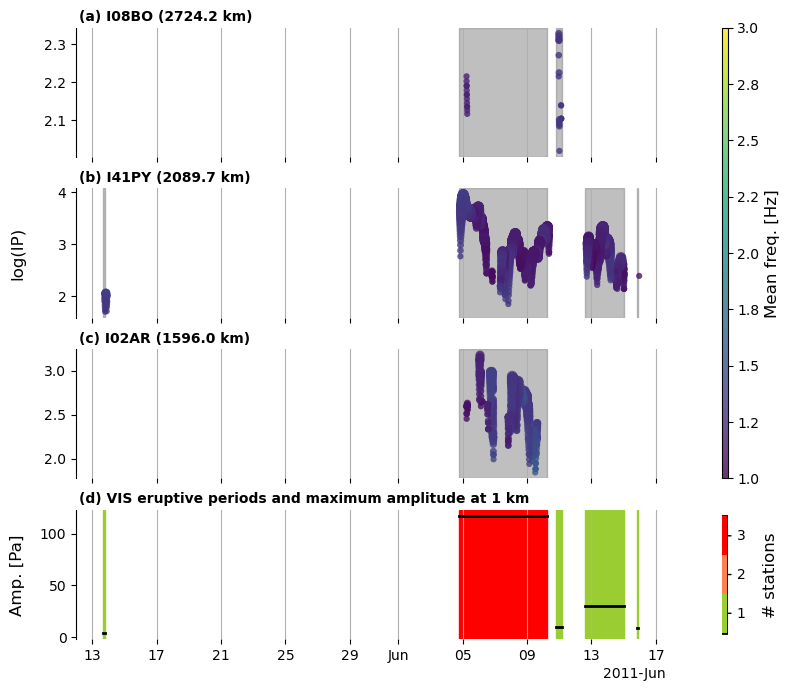

In [51]:
%run -i plot_example.py $this_run

- Panels (a) to (c) show the log(IP) values for each station. Each station is also labeled with the relative distance in km to the source. The gray backgrounds depict the periods with IP values that fulfill all the conditions required by the configuration parameters. In colored circles by frequency (see right colorbar), with size relative to the number of detections, the log(IP) values are displayed. (d) has both the mean amplitude at 1 km from the source in a horizontal black bar, and a colored background (see right colorbar) that shows the time windows of the _candidate eruptions_. 
- You can see above that the June 4 2011 eruption of Cordón Caulle volcano, Chile, was detected by the three stations until June 10 (red background on (d)), with three other possible related eruptive sequencies with only one station of the selected (green background on (d)).
- There are some _false positive_ eruptions detected by one station near May 13. It seems that after June 10, the other _candidate eruptions_ may be related with the 2011 June Cordón Caulle activity, but detected only by I08BO, and later I41PY. This is a matter to figure out (aka, research!).
- This figure was saved in the folder `figures` and named following the run timestamp `20260204T160409-results.png`
- There are many other possible and better ways of displaying these results as well, but this is a good first insight.

# Modifying and running the VIS again

Every monitoring setting has it's own important differences. For example, if we do not use back-azimuth interpolations to deal with the strong seasonal stratospheric wind in the area, we will worsen the results to the point of not being able to detect and characterize the June 2011 eruption of Cordón Caulle volcano.

To see this, we should modify the running parameters so there is no interpolations used, forgint the VIS to look to the geographical back-azimuth +/- the back-azimuth tolerance (`Dazim`).

Fortunately, this is very easy to to with this tool. As the past run configuration file has been saved in `results`, we now can open `../cfg/vis_config.toml` and modify the line

```TOML
BackAziInterp     = './examples/interpolations'
```

with 

```TOML
BackAziInterp     = false
```

and save (overwrite) the file.

**NOTE**: remember to restart the kernel (On top left menu go to Kernel > Restart Kernel).

Now, we need to get out of `examples` to run the VIS again:

In [38]:
import os
import pandas as pd

In [39]:
os.chdir('..')

And run the VIS with the new configuration:

In [ ]:
%run src/vis_main.py

The command above should give you an output similar to this:

- Note the line that says `[db_vis.py     :777] Using static back-azimuth tolerance with DAZIM=3`, meaning that this run will not use the interpolations but a static, geographical back-azimuth value +/- 3 degrees (`DAZIM=3`).`
- Note also that the detections, and veff-ratio values were not reloaded, skipping to the analysis of the data, which took ~6 minutes.
- In this example, the results were saved in `./examples/results/20260205T090709`

Let's look at the eruptions again:

In [32]:
os.chdir('examples')

**Important note**: `this_run` below has the name of the folder based on the *current* date and time you have run the VIS, so please remember to change it accordingly. 

In [52]:
this_run = '20260608T151537'

In [53]:
eruption_results_nobazdev = pd.read_pickle(f"results/{this_run}/eruption_results.pkl")

In [54]:
eruption_results_nobazdev

,Eruption Code,Start Date (UTC),End Date (UTC),Detection Date (UTC),Confidence Level,Last Notification (UTC),Revision,Status,Estimated Amplitude [Pa]
0,Erupt2011160PUYE,2011-06-09 05:18:58.135531+00:00,2011-06-09 08:13:58.135531+00:00,2011-06-09 09:05:00+00:00,1,2026-06-08 22:19:10.001888+00:00,2,ended,11.0
1,Erupt2011158PUYE,2011-06-07 06:08:58.135531+00:00,2011-06-07 17:43:58.135531+00:00,2011-06-07 09:55:00+00:00,1,2026-06-08 22:19:07.305744+00:00,5,ended,10.0


So, we basically lost the actual eruption start (June 4) and perhaps only have false positives.

Let's plot it

-> Figure <figures/20260608T151537-results.png> saved.


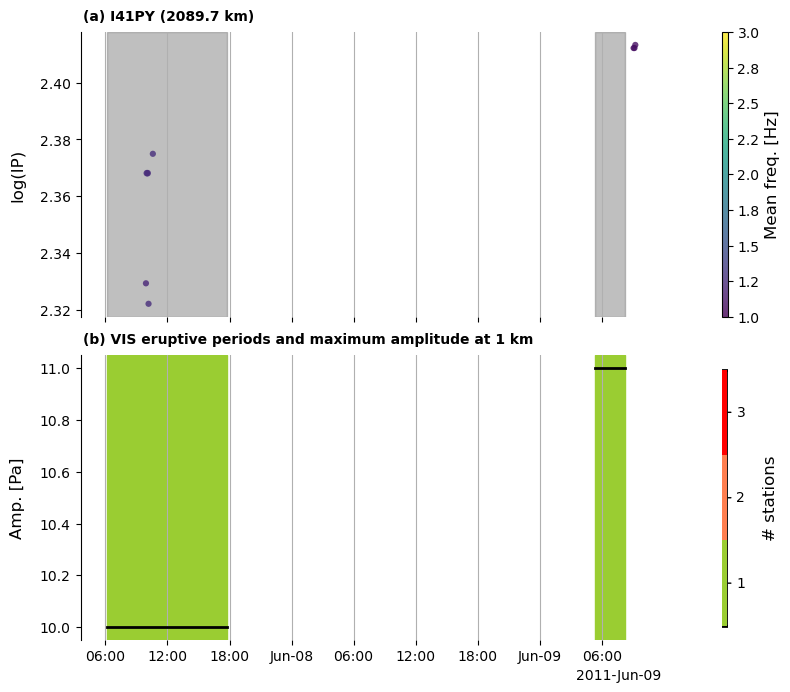

In [55]:
%run plot_example.py $this_run

- This figure is also saved in `figures`. Now you have to results to compare!
- Some interesting things to note:
    - I08BO nor I02AR participated in 'eruption' characterization here.
    - Indeed, the only 'low-frequency' series of detections from I41PY used here partially match the June 4-10 2011 eruption of Cordón Caulle previously seen. These are lucky detections that were not as affected by the regional zonal winds to the east at the moment of the eruption.

## Other configurations

Believe me, there are _many_ possible parametrizations to be tested, depending on the goals. For example:
- What if not using veff-ratios in this case? This is perhaps the most annoying case, but it happens. If there are many detections and you don't want to reload them in a new project folder, you should do the following:
    - backup the folder `veffrat` to a `veffrat_bk`, `compiled_data/veff_ratios.pkl` to `compiled_data/veff_ratios.pkl_bk`
    - copy `compiled_data/processed_files.txt` to `compiled_data/processed_files.txt.bk`
    - edit `compiled_data/processed_files.txt` by erasing the three last lines:
      
          veff50_I41PY_2011-2011_VIS.mat
          veff50_I08BO_2011-2011_VIS.mat
          veff50_I02AR_2011-2011_VIS.mat
    - And run again the VIS. After this, the results should be available in `results`. To go back to using the veff-ratios, you should basically revert the changes with the backups.
- What if you want to add more stations? This is easier:
    - Add the bulletin file to `bulletins`.
    - Change `cfg/vis_config.toml` so the station is listed in the available ones (e.g., `StationList`). Remember to ensure this station is listed by that name in `cfg/stations.csv`
    - Re-run the VIS. As this file is not listed in `compiled_data/processed_files.txt`, it will load it.
- What if you want to add more veff-ratios?
    - Add the veff-ratio file to `veffrat`.
    - Re-run the VIS, similar to previous case.
- What if the data for the stations changed, or the veff-ratios changed/need to be replaced? Well, this is a more diffult case. As the data is compiled into binaries in `compiled_data`, you could either backup/erase the `pkl` files and erase `compiled_data/processed_files.txt` to force the VIS to reload the data, or start a new project in a different folder from scratch. I prefer the second method. If you don't do this, the data should be replaced, but I haven't tested this feature well enough.
- What if the interpolations changed? This is also easier, because the interpolations are not compiled into binaries and applyied on a day-to-day basis in the back-azimuth filter process:
    - Replace the binaries in `interpolations`
    - Re-run. 
- What if you want to change other parameters, like `PersistencyThreshold` or `MaxDist`? This is the easiest, as you only need to change `cfg/vis_config.toml` and re-run the VIS. Nothing else.

So, give it a try!